# 235. Precision at matched recall on SCOPe40 (experiment 1)

The precision claim ("109 pairs at E <= 0.01, zero cross-fold") could be a strict
threshold rather than a property. The test: for each query, take kmerseek's hits at
E <= 0.01 and count its same-superfamily recall; then take MMseqs2 and Foldseek at
whatever cutoff gives the same recall on that query, and count the different-fold hits
they let in on the way. Folddisco convention: same superfamily is a true positive,
different fold is a false positive, same fold but different superfamily is neither.

Kill condition: if MMseqs2 at matched recall is also cross-fold-free, the precision claim
is "a strict threshold" and is written up as such.

Inputs: 500 random SCOPe40 domains (`235_q500.fa`) searched with the extended arm
(hp_thomas_dill k=12, penalty 2, chain 30/10, `region_evalue` with K=0.03), MMseqs2
`-s 7.5` on the same queries against SCOPe40, and the existing Foldseek all-vs-all
(`results-foldseek-pdb/foldseek/foldseek_scope40_pdb.tsv.gz`) restricted to them. Every
tool's rows are reduced to one best hit per query-target pair and self-hits are dropped.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

sys.path.insert(0, str(Path.cwd()))
import hp_conservation_utils as hc

pl.Config.set_tbl_rows(60)
pl.Config.set_tbl_width_chars(220)
FIG = Path("../figures")
SC = Path("/Users/olga/data/scope")
E_K = 0.01

lk = pl.read_csv(SC / "results-foldseek-pdb/scope_domains.tsv", separator="\t")
sf = dict(zip(lk["domain_id"], lk["scop_superfamily"]))
fold = dict(zip(lk["domain_id"], lk["scop_fold"]))
queries = [l[1:].split()[0] for l in open(SC / "235_q500.fa") if l.startswith(">")]
n_sf = {q: sum(1 for t, s in sf.items() if s == sf[q] and t != q) for q in queries}


def label(df):
    return (
        df.filter(pl.col("q") != pl.col("t"))
        .with_columns(
            pl.col("q").replace_strict(sf, default=None).alias("qsf"),
            pl.col("t").replace_strict(sf, default=None).alias("tsf"),
            pl.col("q").replace_strict(fold, default=None).alias("qf"),
            pl.col("t").replace_strict(fold, default=None).alias("tf"),
        )
        .with_columns(
            (pl.col("qsf") == pl.col("tsf")).alias("tp"),
            (pl.col("qf") != pl.col("tf")).alias("fp"),
        )
    )


km = label(
    pl.read_parquet(SC / "235_kmerseek_ext_k12_q500_pairs.parquet").rename(
        {"evalue": "score"}
    )
)
mm = label(
    pl.read_csv(
        SC / "235_mmseqs2_q500.tsv",
        separator="\t",
        has_header=False,
        new_columns=["q", "t", "score", "bits", "pident"],
    )
    .group_by("q", "t")
    .agg(pl.col("score").min())
)
fs = label(
    pl.read_csv(
        SC / "results-foldseek-pdb/foldseek/foldseek_scope40_pdb.tsv.gz",
        separator="\t",
        has_header=False,
        new_columns=["q", "t", "bits", "score"],
    )
    .filter(pl.col("q").is_in(queries))
    .group_by("q", "t")
    .agg(pl.col("score").min())
)
TOOLS = {"kmerseek ext k12 (E-value)": km, "MMseqs2 -s 7.5": mm, "Foldseek": fs}
for name, d in TOOLS.items():
    print(
        f"{name:28s} pairs {d.height:>9,}  queries with hits {d['q'].n_unique():>4}  TP pairs {int(d['tp'].sum()):>6,}"
    )

kmerseek ext k12 (E-value)   pairs 6,579,145  queries with hits  500  TP pairs 25,537
MMseqs2 -s 7.5               pairs     5,521  queries with hits  481  TP pairs  3,983
Foldseek                     pairs   181,078  queries with hits  457  TP pairs 16,666


## 1. Matched-recall comparison

Per query: kmerseek's recall at E <= 0.01 sets the target; each other tool is walked down
its own ranking until it has found that many same-superfamily relatives (or runs out of
hits), and the different-fold hits it passed are counted. Queries where kmerseek finds
nothing at E <= 0.01 contribute no comparison and are reported separately.

queries with superfamily relatives: 473; kmerseek finds >=1 at E<=0.01: 124
shape: (3, 6)
┌────────────────────────────┬──────────────────────┬───────────────┬───────────┬─────────────────────────────────┬────────────────────────────────┐
│ tool                       ┆ TP at matched recall ┆ cross-fold FP ┆ precision ┆ queries reaching kmerseek's re… ┆ queries with >=1 cross-fold FP │
│ ---                        ┆ ---                  ┆ ---           ┆ ---       ┆ ---                             ┆ ---                            │
│ str                        ┆ i64                  ┆ i64           ┆ f64       ┆ f64                             ┆ i64                            │
╞════════════════════════════╪══════════════════════╪═══════════════╪═══════════╪═════════════════════════════════╪════════════════════════════════╡
│ kmerseek ext k12 (E-value) ┆ 302                  ┆ 1             ┆ 0.9967    ┆ 1.0                             ┆ 1                              │
│ MMseqs2 -s 7.5

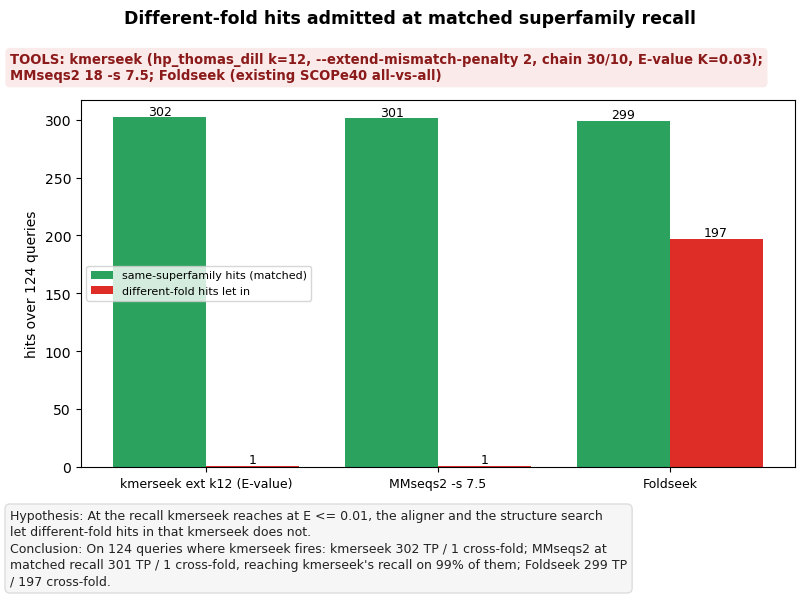

In [2]:
def matched(km_q, other_q, tp_target):
    o = other_q.sort("score")
    tps = fps = 0
    for tp, fp in zip(o["tp"], o["fp"]):
        if tps >= tp_target:
            break
        if tp:
            tps += 1
        elif fp:
            fps += 1
    return tps, fps


rows = []
km_by = {k[0]: g for k, g in km.group_by("q")}
oth_by = {
    name: {k[0]: g for k, g in d.group_by("q")}
    for name, d in TOOLS.items()
    if not name.startswith("kmerseek")
}
for q in queries:
    if n_sf[q] == 0:
        continue
    g = km_by.get(q)
    if g is None:
        rows.append({"q": q, "n_sf": n_sf[q], "tp_k": 0, "fp_k": 0})
        continue
    at = g.filter(pl.col("score") <= E_K)
    r = {
        "q": q,
        "n_sf": n_sf[q],
        "tp_k": int(at["tp"].sum()),
        "fp_k": int(at["fp"].sum()),
    }
    for name, by in oth_by.items():
        og = by.get(q)
        if og is None:
            r[f"tp_{name}"], r[f"fp_{name}"] = 0, 0
        else:
            r[f"tp_{name}"], r[f"fp_{name}"] = matched(g, og, r["tp_k"])
    rows.append(r)
mt = pl.DataFrame(rows)
fired = mt.filter(pl.col("tp_k") > 0)
print(
    f"queries with superfamily relatives: {mt.height}; kmerseek finds >=1 at E<={E_K}: {fired.height}"
)
summary = []
for name in TOOLS:
    key = "k" if name.startswith("kmerseek") else name
    tp, fp = fired[f"tp_{key}"].sum(), fired[f"fp_{key}"].sum()
    reached = (fired[f"tp_{key}"] >= fired["tp_k"]).mean() if key != "k" else 1.0
    summary.append(
        {
            "tool": name,
            "TP at matched recall": int(tp),
            "cross-fold FP": int(fp),
            "precision": tp / max(tp + fp, 1),
            "queries reaching kmerseek's recall": float(reached),
            "queries with >=1 cross-fold FP": int((fired[f"fp_{key}"] > 0).sum()),
        }
    )
summary = pl.DataFrame(summary)
print(summary)

fig, ax = plt.subplots(figsize=(8, 4.2))
x = np.arange(summary.height)
ax.bar(
    x - 0.2,
    summary["TP at matched recall"],
    0.4,
    color="#2ca25f",
    label="same-superfamily hits (matched)",
)
ax.bar(
    x + 0.2,
    summary["cross-fold FP"],
    0.4,
    color="#de2d26",
    label="different-fold hits let in",
)
for i, r in enumerate(summary.iter_rows(named=True)):
    ax.text(
        i + 0.2,
        r["cross-fold FP"] + 2,
        f"{r['cross-fold FP']}",
        ha="center",
        fontsize=9,
    )
    ax.text(
        i - 0.2,
        r["TP at matched recall"] + 2,
        f"{r['TP at matched recall']}",
        ha="center",
        fontsize=9,
    )
ax.set_xticks(x, summary["tool"], fontsize=9)
ax.set_ylabel(f"hits over {fired.height} queries")
ax.legend(fontsize=8)
s = {r["tool"]: r for r in summary.iter_rows(named=True)}
hc.finish_figure(
    fig,
    FIG / "235_matched_recall_crossfold.png",
    tools="kmerseek (hp_thomas_dill k=12, --extend-mismatch-penalty 2, chain 30/10, E-value K=0.03); MMseqs2 18 -s 7.5; Foldseek (existing SCOPe40 all-vs-all)",
    hypothesis="At the recall kmerseek reaches at E <= 0.01, the aligner and the structure search let different-fold hits in that kmerseek does not.",
    conclusion=(
        f"On {fired.height} queries where kmerseek fires: kmerseek {s['kmerseek ext k12 (E-value)']['TP at matched recall']} TP / {s['kmerseek ext k12 (E-value)']['cross-fold FP']} cross-fold; "
        f"MMseqs2 at matched recall {s['MMseqs2 -s 7.5']['TP at matched recall']} TP / {s['MMseqs2 -s 7.5']['cross-fold FP']} cross-fold, reaching kmerseek's recall on {100 * s['MMseqs2 -s 7.5']['queries reaching kmerseek\'s recall']:.0f}% of them; "
        f"Foldseek {s['Foldseek']['TP at matched recall']} TP / {s['Foldseek']['cross-fold FP']} cross-fold."
    ),
    title="Different-fold hits admitted at matched superfamily recall",
)

## 2. Top-1 / top-5 precision and sensitivity to the first false positive

All queries with at least one superfamily relative; a query with no ranked hits scores 0
on sensitivity and is excluded from the top-k precision (which is a property of hits).
Top-k precision counts same-superfamily as correct and different-fold as wrong among the
top k; same-fold/different-superfamily hits are skipped.

shape: (3, 6)
┌────────────────────────────┬────────────────────────────┬─────────────────┬─────────────────┬────────────────┬─────────┐
│ tool                       ┆ sens_first_fp (unranked=0) ┆ top-1 precision ┆ top-5 precision ┆ queries ranked ┆ queries │
│ ---                        ┆ ---                        ┆ ---             ┆ ---             ┆ ---            ┆ ---     │
│ str                        ┆ f64                        ┆ f64             ┆ f64             ┆ i64            ┆ i64     │
╞════════════════════════════╪════════════════════════════╪═════════════════╪═════════════════╪════════════════╪═════════╡
│ kmerseek ext k12 (E-value) ┆ 0.071542                   ┆ 0.429175        ┆ 0.235518        ┆ 473            ┆ 473     │
│ MMseqs2 -s 7.5             ┆ 0.278111                   ┆ 0.842451        ┆ 0.691211        ┆ 457            ┆ 473     │
│ Foldseek                   ┆ 0.570728                   ┆ 0.970046        ┆ 0.839823        ┆ 436            ┆ 473     │
└─

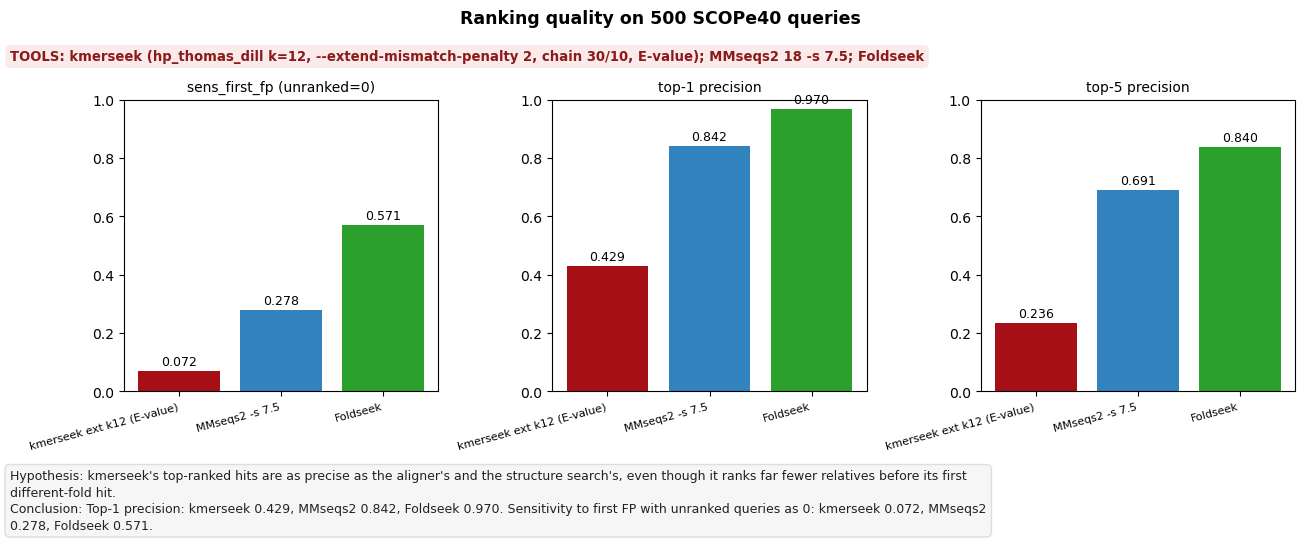

In [3]:
def per_query_metrics(d):
    out = []
    by = {k[0]: g.sort("score") for k, g in d.group_by("q")}
    for q in queries:
        if n_sf[q] == 0:
            continue
        g = by.get(q)
        if g is None:
            out.append(
                {"q": q, "sens": 0.0, "top1": None, "top5": None, "ranked": False}
            )
            continue
        found = 0
        for tp, fp in zip(g["tp"], g["fp"]):
            if fp:
                break
            if tp:
                found += 1
        scored = g.filter(pl.col("tp") | pl.col("fp"))
        t1 = float(scored["tp"][:1].mean()) if scored.height else None
        t5 = float(scored["tp"][:5].mean()) if scored.height else None
        out.append(
            {"q": q, "sens": found / n_sf[q], "top1": t1, "top5": t5, "ranked": True}
        )
    return pl.DataFrame(out)


pq = {name: per_query_metrics(d) for name, d in TOOLS.items()}
tab = pl.DataFrame(
    [
        {
            "tool": n,
            "sens_first_fp (unranked=0)": p["sens"].mean(),
            "top-1 precision": p["top1"].mean(),
            "top-5 precision": p["top5"].mean(),
            "queries ranked": int(p["ranked"].sum()),
            "queries": p.height,
        }
        for n, p in pq.items()
    ]
)
print(tab)
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, col in zip(
    axes, ["sens_first_fp (unranked=0)", "top-1 precision", "top-5 precision"]
):
    ax.bar(range(tab.height), tab[col], color=["#a50f15", "#3182bd", "#2ca02c"])
    ax.set_xticks(range(tab.height), tab["tool"], fontsize=8, rotation=15, ha="right")
    ax.set_title(col, fontsize=10)
    ax.set_ylim(0, 1)
    for i, v in enumerate(tab[col]):
        ax.text(i, v + 0.02, f"{v:.3f}", ha="center", fontsize=9)
t = {r["tool"]: r for r in tab.iter_rows(named=True)}
hc.finish_figure(
    fig,
    FIG / "235_topk_precision_sensitivity.png",
    tools="kmerseek (hp_thomas_dill k=12, --extend-mismatch-penalty 2, chain 30/10, E-value); MMseqs2 18 -s 7.5; Foldseek",
    hypothesis="kmerseek's top-ranked hits are as precise as the aligner's and the structure search's, even though it ranks far fewer relatives before its first different-fold hit.",
    conclusion=(
        f"Top-1 precision: kmerseek {t['kmerseek ext k12 (E-value)']['top-1 precision']:.3f}, MMseqs2 {t['MMseqs2 -s 7.5']['top-1 precision']:.3f}, Foldseek {t['Foldseek']['top-1 precision']:.3f}. "
        f"Sensitivity to first FP with unranked queries as 0: kmerseek {t['kmerseek ext k12 (E-value)']['sens_first_fp (unranked=0)']:.3f}, MMseqs2 {t['MMseqs2 -s 7.5']['sens_first_fp (unranked=0)']:.3f}, Foldseek {t['Foldseek']['sens_first_fp (unranked=0)']:.3f}."
    ),
    title="Ranking quality on 500 SCOPe40 queries",
)

## 3. Verdict

The kill condition fired. On the 124 queries where kmerseek finds at least one
superfamily relative at E <= 0.01, it returns 302 true and 1 different-fold hit; MMseqs2
walked to the same recall returns 301 true and 1 different-fold hit, and reaches
kmerseek's recall on 99% of those queries. The precision at E <= 0.01 is a strict
threshold, not a property of the per-pair lambda, and is to be written up as such.

Foldseek at matched recall admits 197 different-fold hits, but that is the matched-recall
walk reaching into its tail on queries where kmerseek's E <= 0.01 set happens to be large;
on every unconditional measure Foldseek leads (sensitivity to first FP 0.57, top-1 0.97).

Ranking quality without the threshold is where kmerseek is weakest: top-1 precision 0.43
against 0.84 (MMseqs2) and 0.97 (Foldseek), sensitivity to first FP 0.072 against 0.28 and
0.57. Its first-ranked hit is wrong more often than right because it ranks 6.6 M pairs
for 500 queries and most of a query's list is composition noise sitting just above
E = 0.01. A seed budget or two-hit rule, not a better statistic, is what would change that.